In [25]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl
%config InlineBackend.figure_format='retina'

import numpy as np
import networkx as nx
from idtxl.estimators_jidt import JidtDiscreteMI, JidtDiscreteCMI
import dit
import matplotlib.pyplot as plt
import os, sys
os.environ['JAVA_HOME'] = '/Users/jaime/miniconda3/envs/ma-aif-dit/lib/jvm'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
%store -r all_partition_timeseries

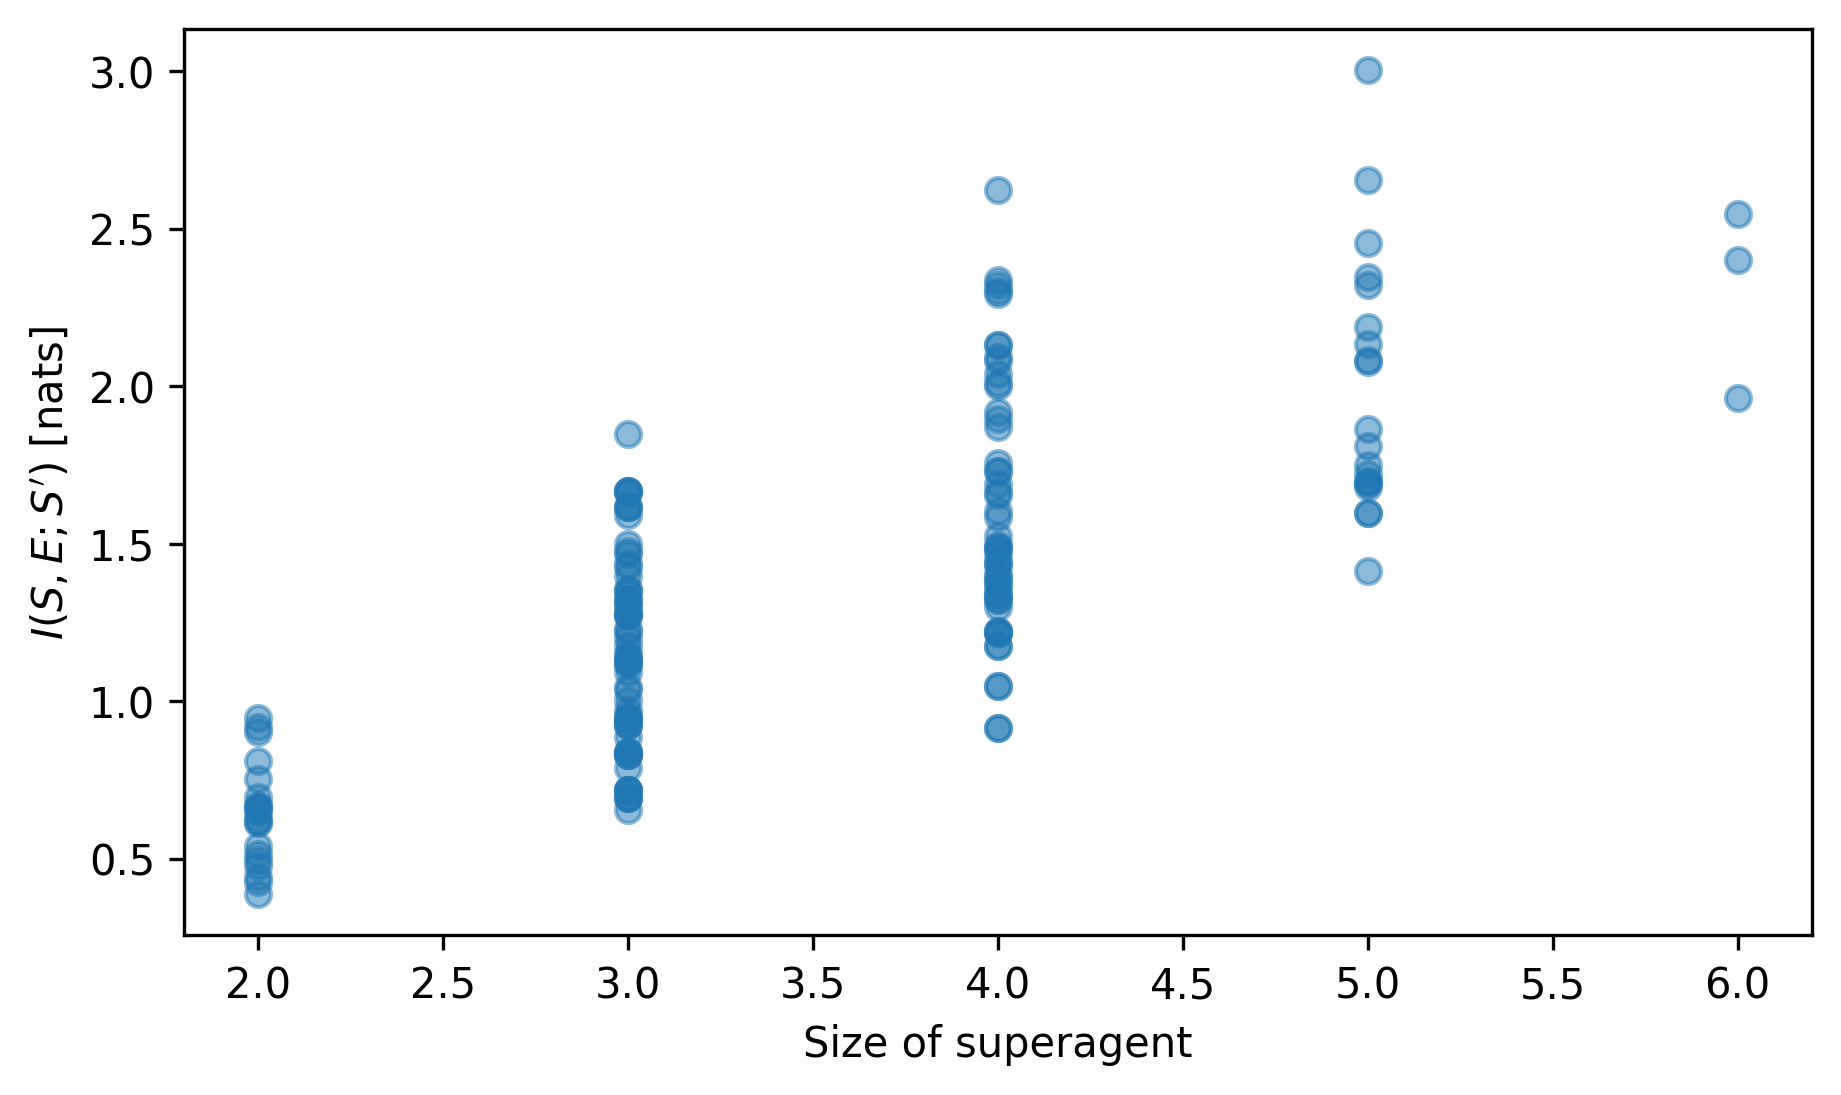

In [ ]:
# I(S, E; S') ------------------------------------------------------------------
results = []
for S_history, E_history in all_partition_timeseries:
    mi_estimator = JidtDiscreteMI()
    source = np.hstack((S_history[:-1], E_history[:-1]))
    target = S_history[1:]
    mi_result = mi_estimator.estimate(source, target)
    results.append((mi_result, S_history.shape[1], E_history.shape[1]))


plt.figure(figsize=(7, 4), dpi=150)
# Extract the first and second elements from the results list
x = [r[1] for r in results]
y = [r[0] for r in results]

# Create a scatterplot
plt.scatter(x, y, alpha=0.5)
plt.ylabel("$I(S, E; S')$ [nats]")
plt.xlabel('Size of superagent')
plt.show()

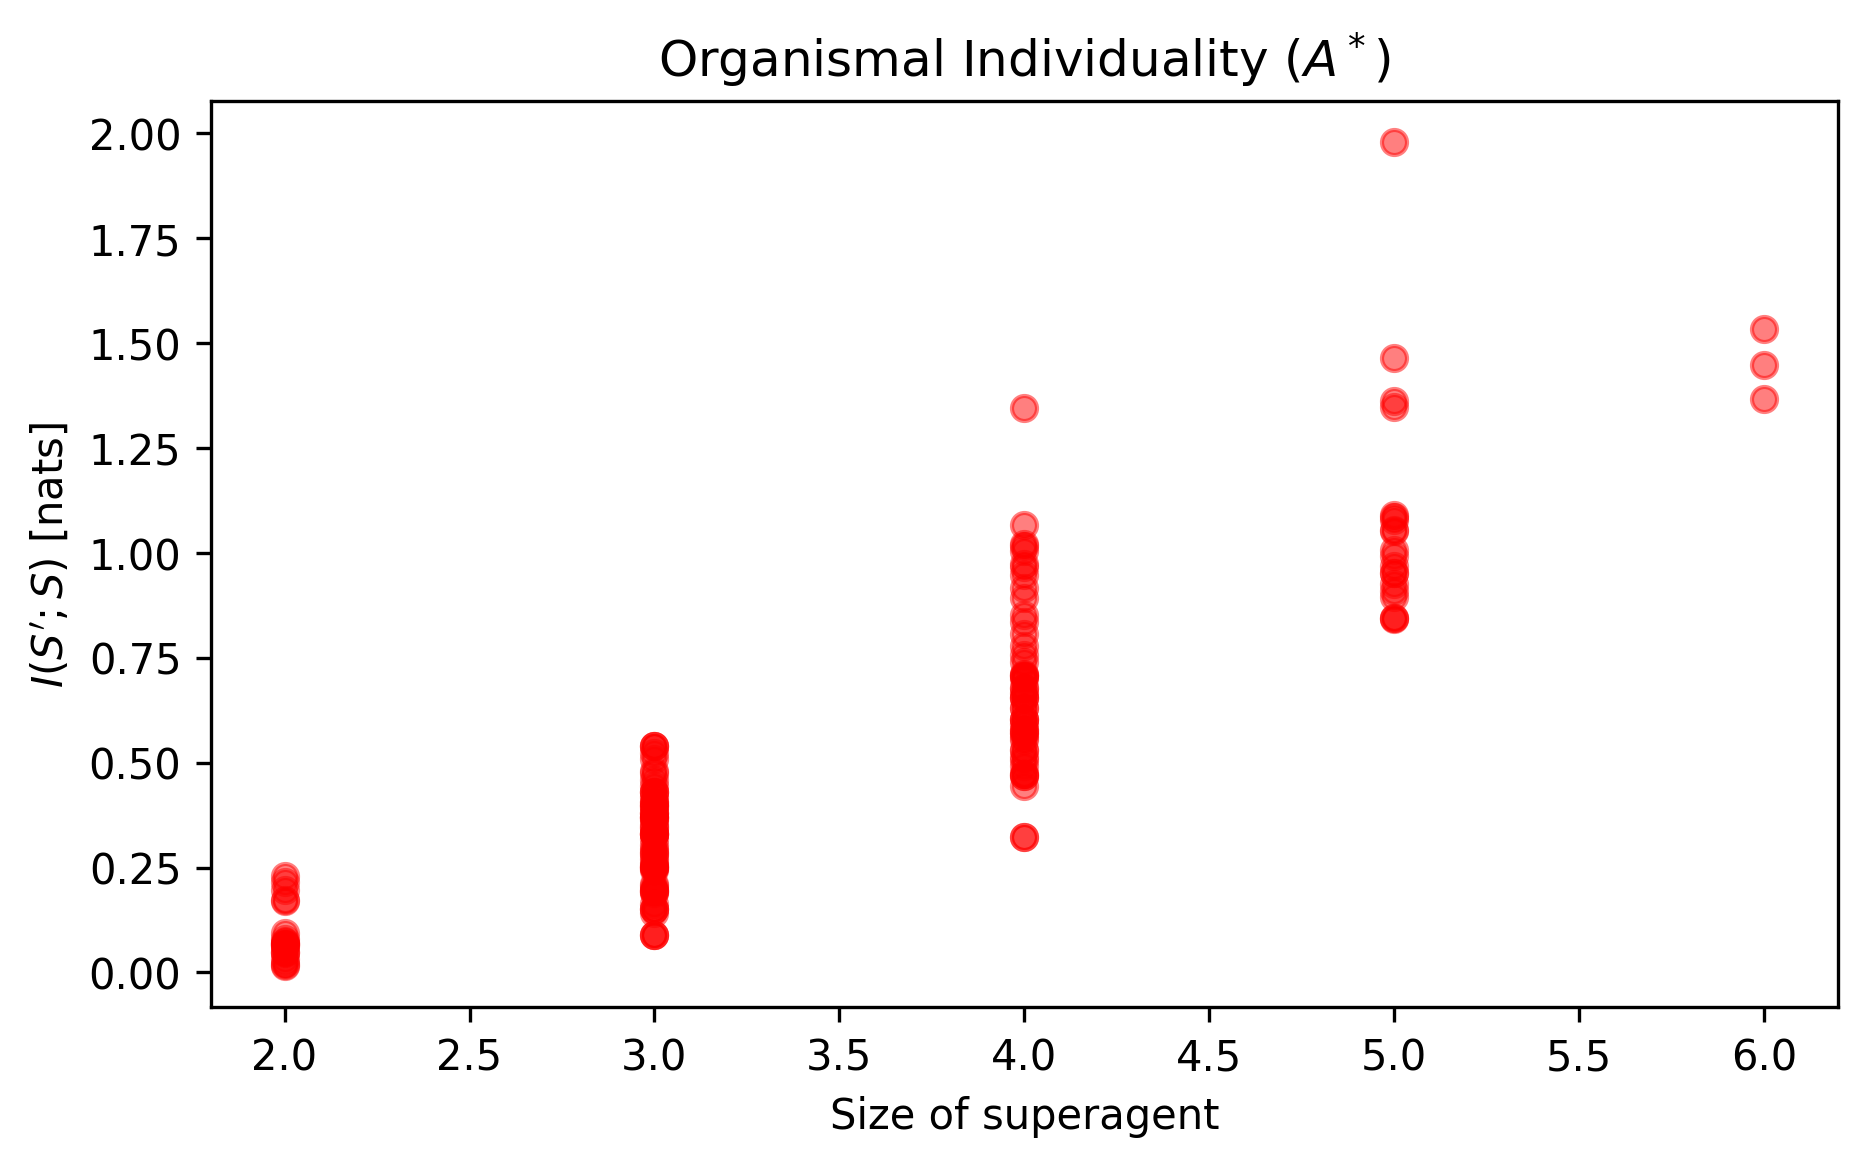

In [28]:
results = []
for S_history, E_history in all_partition_timeseries:
    mi_estimator = JidtDiscreteMI()
    source = S_history[:-1]
    target = S_history[1:]
    mi_result = mi_estimator.estimate(source, target)
    results.append((mi_result, S_history.shape[1], E_history.shape[1]))


plt.figure(figsize=(7, 4), dpi=150)
# Extract the first and second elements from the results list
x = [r[1] for r in results]
y = [r[0] for r in results]

# Create a scatterplot
plt.scatter(x, y, alpha=0.5, c='red')
plt.ylabel("$I(S' ; S)$ [nats]")
plt.xlabel('Size of superagent')
plt.title('Organismal Individuality ($A^*$)')
plt.show()

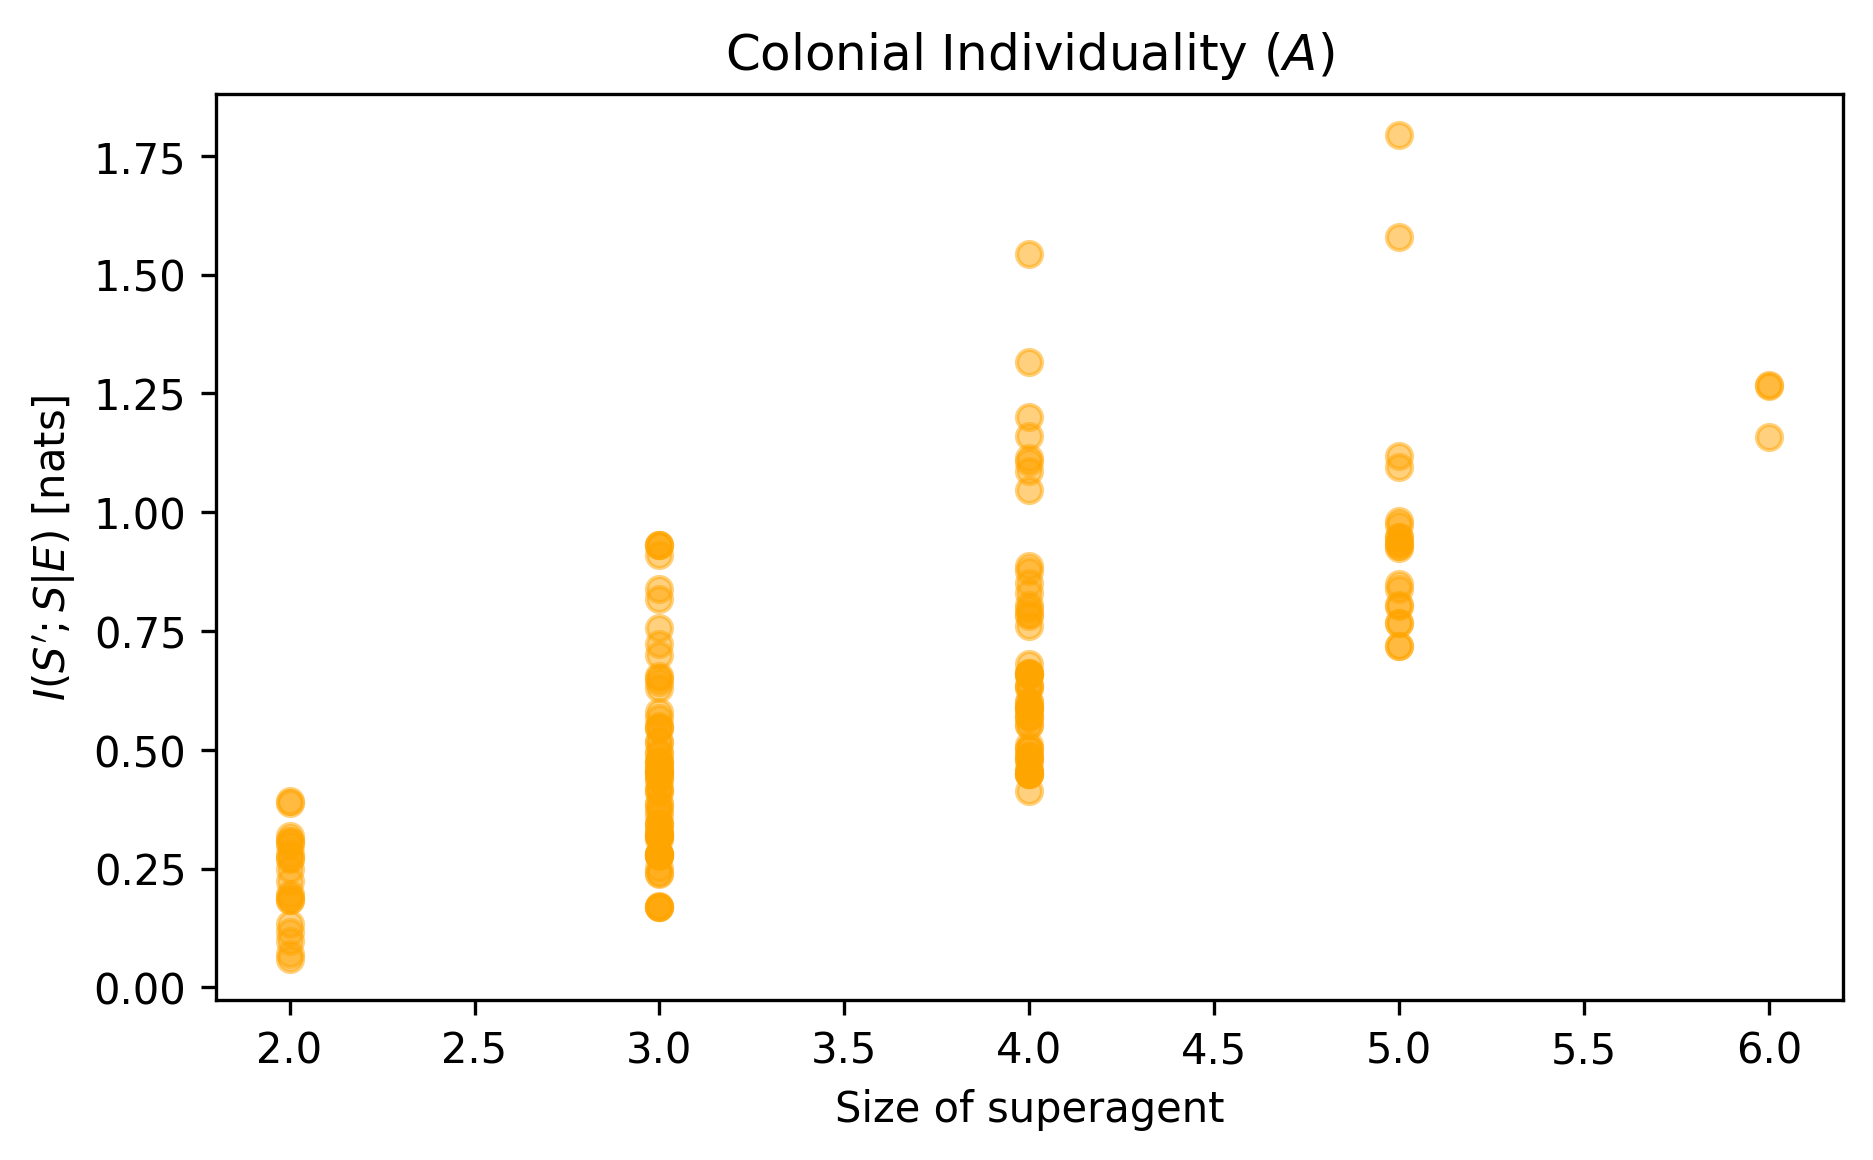

In [30]:
results = []
for S_history, E_history in all_partition_timeseries:
    cmi_estimator = JidtDiscreteCMI()
    source = S_history[:-1]
    target = S_history[1:]
    mi_result = cmi_estimator.estimate(source, target, conditional=E_history[:-1])
    results.append((mi_result, S_history.shape[1], E_history.shape[1]))


plt.figure(figsize=(7, 4), dpi=150)
# Extract the first and second elements from the results list
x = [r[1] for r in results]
y = [r[0] for r in results]

# Create a scatterplot
plt.scatter(x, y, alpha=0.5, c='orange')
plt.ylabel("$I(S'; S | E)$ [nats]")
plt.xlabel('Size of superagent')
plt.title('Colonial Individuality ($A$)')
plt.show()

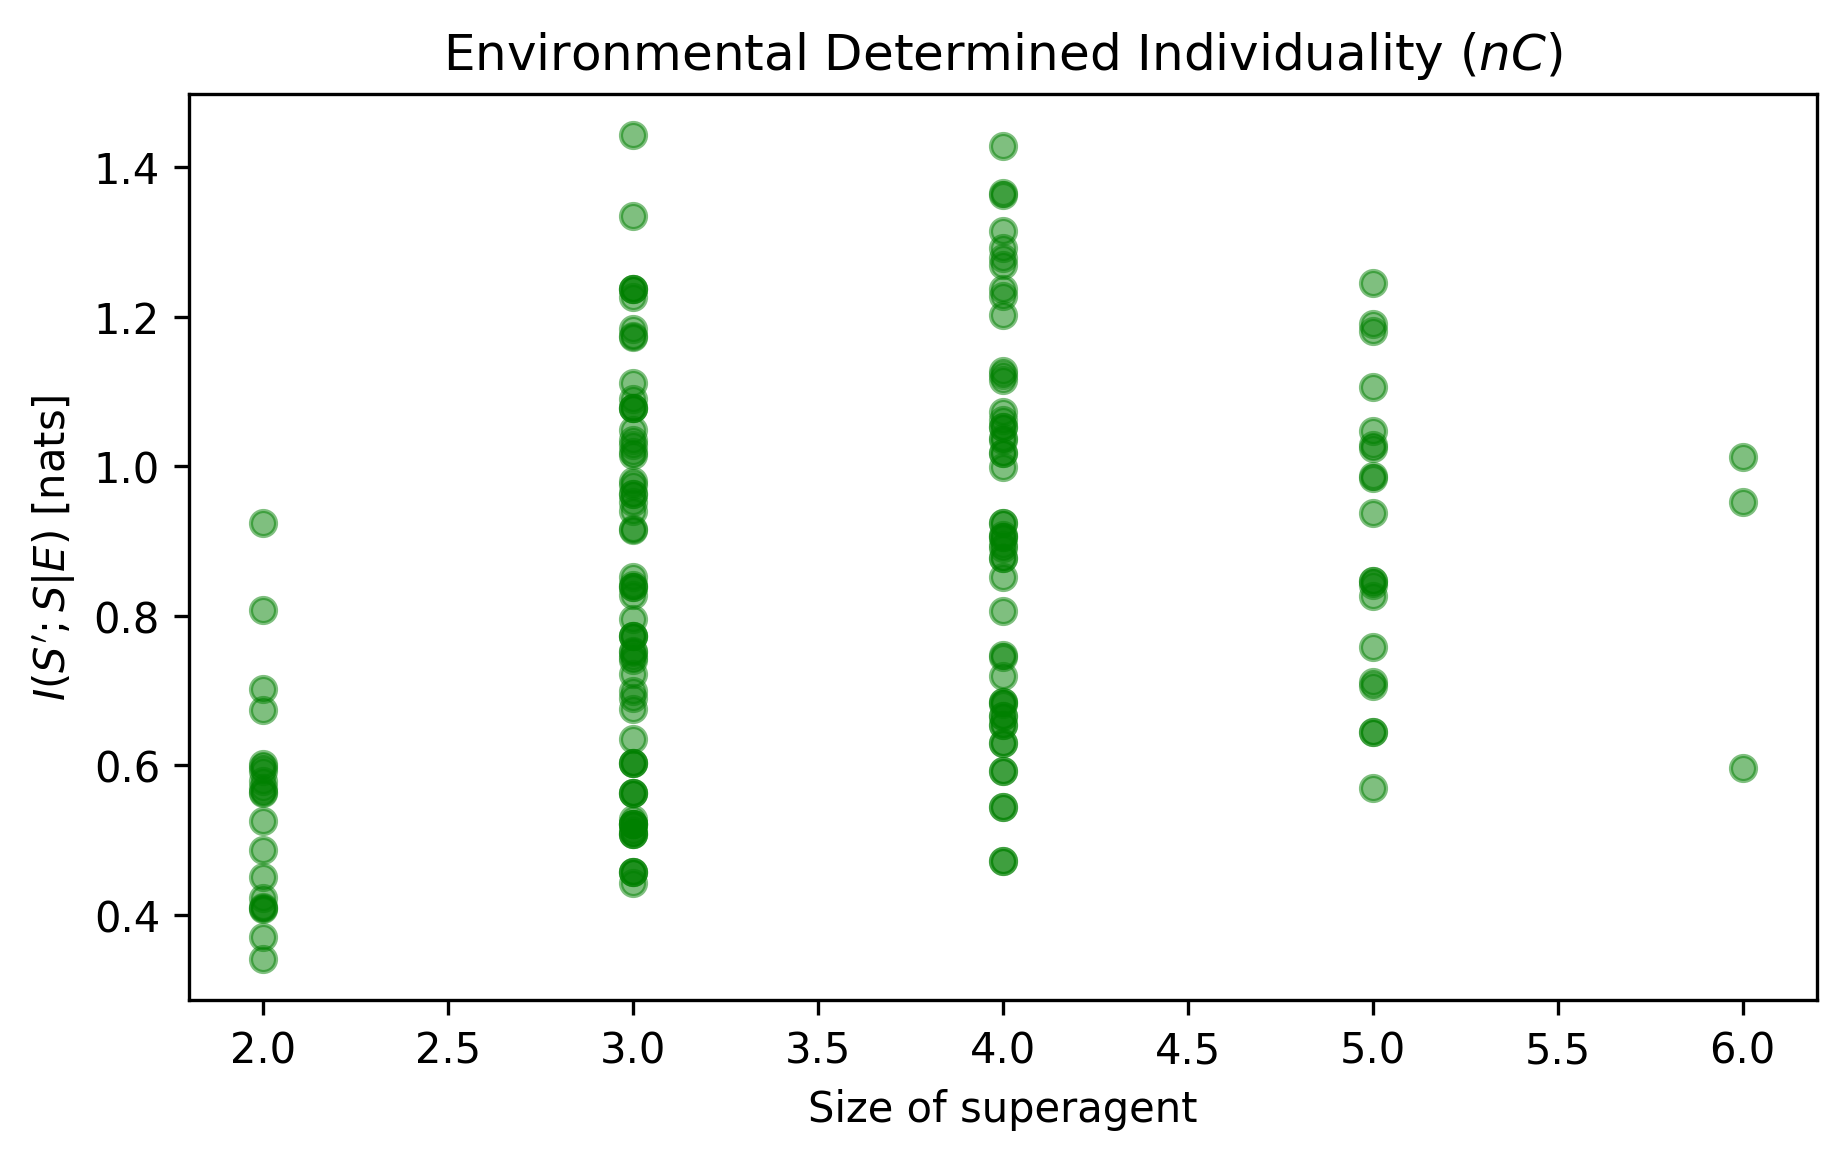

In [ ]:
results = []
for S_history, E_history in all_partition_timeseries:
    cmi_estimator = JidtDiscreteCMI()
    source = E_history[:-1]
    target = S_history[1:]
    mi_result = cmi_estimator.estimate(source, target, conditional=S_history[:-1])
    results.append((mi_result, S_history.shape[1], E_history.shape[1]))


plt.figure(figsize=(7, 4), dpi=150)
# Extract the first and second elements from the results list
x = [r[1] for r in results]
y = [r[0] for r in results]

# Create a scatterplot
plt.scatter(x, y, alpha=0.5, c='green')
plt.ylabel("$I(S'; E | S)$ [nats]")
plt.xlabel('Size of superagent')
plt.title('Environmental Determined Individuality ($nC$)')
plt.show()